In [1]:
import os
from io import BytesIO

import requests
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

os.makedirs("data", exist_ok=True)

# United States bounding box
LON_MIN, LAT_MIN, LON_MAX, LAT_MAX = -125, 24, -66, 50

# Image size
WIDTH = 1000
HEIGHT = 500

# Date used for precipitation layer
DATE = "2021-11-25"

BASE_WMS_URL = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"

In [2]:
def load_wms_layer(layer_name, date=DATE, width=WIDTH, height=HEIGHT):
    params = {
        "service": "WMS",
        "version": "1.1.1",
        "request": "GetMap",
        "layers": layer_name,
        "styles": "",
        "format": "image/png",
        "transparent": "true",
        "srs": "EPSG:4326",
        "bbox": f"{LON_MIN},{LAT_MIN},{LON_MAX},{LAT_MAX}",
        "width": width,
        "height": height,
        "time": date,
    }

    response = requests.get(BASE_WMS_URL, params=params)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content)).convert("RGBA")
    return np.array(img)

In [3]:
crop_layer = "Agricultural_Lands_Croplands_2000"
precip_layer = "IMERG_Precipitation_Rate"

crop_img = load_wms_layer(crop_layer)
precip_img = load_wms_layer(precip_layer)

print("Crop image shape:", crop_img.shape)
print("Precip image shape:", precip_img.shape)

Crop image shape: (500, 1000, 4)
Precip image shape: (500, 1000, 4)


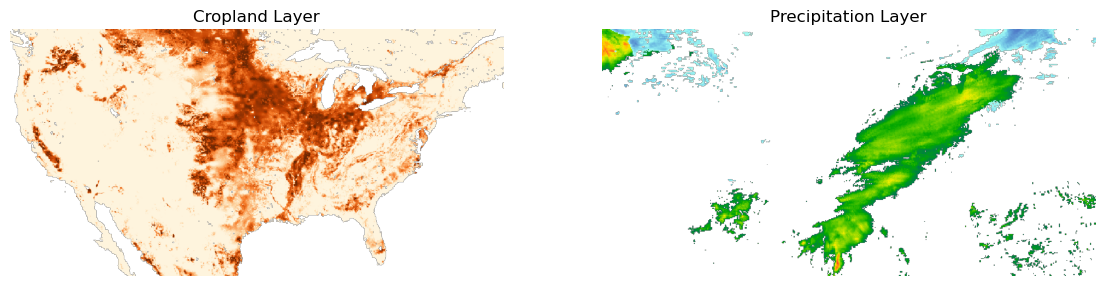

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(crop_img)
axes[0].set_title("Cropland Layer")
axes[0].axis("off")

axes[1].imshow(precip_img)
axes[1].set_title("Precipitation Layer")
axes[1].axis("off")

plt.show()

In [5]:
h, w = crop_img.shape[:2]

rows, cols = np.indices((h, w))

lon = LON_MIN + (cols / (w - 1)) * (LON_MAX - LON_MIN)
lat = LAT_MAX - (rows / (h - 1)) * (LAT_MAX - LAT_MIN)

# Crop proxy: use green channel as approximate cropland-density proxy
crop_density = crop_img[:, :, 1].astype(float)

# Precipitation proxy: mean RGB intensity
precip_rgb = precip_img[:, :, :3].astype(float)
precip_intensity = precip_rgb.mean(axis=2)

r_channel = precip_img[:, :, 0].astype(float)
g_channel = precip_img[:, :, 1].astype(float)
b_channel = precip_img[:, :, 2].astype(float)

# Approximate rain/snow proxies based on color channels
rain_proxy = np.where(
    (g_channel > b_channel) | (r_channel > b_channel),
    (r_channel + g_channel) / 2,
    0
)

snow_proxy = np.where(
    (b_channel > r_channel) & (b_channel > g_channel),
    b_channel,
    0
)

df = pd.DataFrame({
    "lon": lon.flatten(),
    "lat": lat.flatten(),
    "crop_density": crop_density.flatten(),
    "precip_intensity": precip_intensity.flatten(),
    "rain_proxy": rain_proxy.flatten(),
    "snow_proxy": snow_proxy.flatten(),
})

df.head()

,lon,lat,crop_density,precip_intensity,rain_proxy,snow_proxy
0,-125.000000,50.0,0.0,102.333333,153.5,0.0
1,-124.940941,50.0,0.0,102.333333,153.5,0.0
2,-124.881882,50.0,0.0,94.666667,142.0,0.0
3,-124.822823,50.0,0.0,91.000000,136.5,0.0
4,-124.763764,50.0,0.0,91.000000,136.5,0.0


In [6]:
# Remove very low-value background pixels
df_clean = df[
    (df["crop_density"] > 10) &
    (df["precip_intensity"] > 10)
].copy()

df_clean["crop_zone"] = pd.cut(
    df_clean["crop_density"],
    bins=[0, 85, 170, 255],
    labels=["Non-Agricultural", "Sparse Crops", "Intense Cropland"],
    include_lowest=True
)

# Sample points for D3 performance
df_points = df_clean.sample(
    n=min(12000, len(df_clean)),
    random_state=42
)

df_summary = df_clean.groupby("crop_zone", observed=True).agg(
    avg_crop_density=("crop_density", "mean"),
    avg_precip=("precip_intensity", "mean"),
    avg_rain=("rain_proxy", "mean"),
    avg_snow=("snow_proxy", "mean"),
    count=("crop_density", "size")
).reset_index()

df_points.to_csv("data/crop_precip_points.csv", index=False)
df_summary.to_csv("data/crop_zone_summary.csv", index=False)

print("Exported:")
print("data/crop_precip_points.csv", df_points.shape)
print("data/crop_zone_summary.csv", df_summary.shape)

df_summary

Exported:
data/crop_precip_points.csv (12000, 7)
data/crop_zone_summary.csv (3, 6)


,crop_zone,avg_crop_density,avg_precip,avg_rain,avg_snow,count
0,Non-Agricultural,62.023153,85.953527,121.234900,1.056372,9934
1,Sparse Crops,124.544135,86.146165,116.302403,2.572448,12609
2,Intense Cropland,232.701772,116.683016,95.675318,45.460185,48198
